## Cargamos las Librerías:

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import warnings
from typing import Optional
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
import os
import sys

## Cargamos el Conjuntos de Datos:

In [2]:
homicidios = pl.read_csv('~/homicidios/data/final/homicidios_final.csv')
homicidios

ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,sem_gest,gramos,dia_ocurr,mes_ocurr,anio_ocur,dia_regis,mes_regis,anio_regis,dia_nacim,mes_nacim,anio_nacim,cond_act,ocupacion,escolarida,edo_civil,tipo_defun,ocurr_trab,lugar_ocur,par_agre,vio_fami,asist_medi,cirugia,natviole,necropsia,usonecrops,encefalica,donador,sitio_ocur,cond_cert,derechohab,embarazo,rel_emba,horas,minutos,capitulo,grupo,lista1,gr_lismex,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str
1,32,"""500 000 a 999 999 habitantes""","""Neumonía, no especificada""",null,"""Neumonía""","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Setenta y tres años …","""No aplica""",null,18,12,2022,4,1,2023,8,"""Abril""",1949,"""Sí""","""Profesores y especialistas en …","""Profesional""","""Divorciado(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No especificada""","""No aplica""","""ISSSTE""","""Otro médico""","""IMSS""","""No especificada ""","""No especificada""","""Veintiún horas""","""Cincuenta minutos""","""Otras enfermedades del sistema…","""Tumores (neoplasias) de compor…","""Neumonía""",null,"""Urbana""","""De 70 a 74 años""","""No especificada""","""Dieciocho días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Zacatecas"""
1,1,"""500 000 a 999 999 habitantes""","""Síndrome de dificultad respira…",null,"""Las demás enfermedades del apa…","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Setenta y siete años …","""No aplica""",null,12,12,2022,4,1,2023,12,"""Julio""",1945,"""No""","""No trabaja""","""Sin escolaridad""","""Soltero(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No""","""No aplica""","""Secretaría de salud""","""Médico tratante""","""Ninguna""","""No especificada ""","""No especificada""","""Cero horas""","""Cincuenta minutos""","""Otras enfermedades del sistema…","""Otros trastornos del ojo y sus…","""Resto de enfermedades del sist…",null,"""Urbana""","""De 75 a 79 años""","""No especificada""","""Doce días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Aguascalientes"""
1,1,"""500 000 a 999 999 habitantes""","""Enfermedad pulmonar obstructiv…",null,"""Enfermedades pulmonares obstru…","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Sesenta y nueve años …","""No aplica""",null,17,12,2022,4,1,2023,24,"""Octubre""",1953,"""No""","""No trabaja""","""Primaria incompleta""","""Viudo(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No""","""No aplica""","""Secretaría de salud""","""Otro médico""","""Ninguna""","""No especificada ""","""No especificada""","""Veinte horas""","""Quince minutos""","""Otras enfermedades del sistema…","""Trastorno mental no especific…","""Enfermedades crónicas de las …",null,"""Urbana""","""De 65 a 69 años""","""No especificada""","""Diecisiete días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Aguasc

## Establecemos los Parámetros de los Gráficos:

In [6]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

owid_palette = [
    "#4e79a7", "#f28e2b", "#e15759", 
    "#76b7b2", "#59a14f", "#edc948", "#b07aa1"
]

gender_palette = {
    "Mujer": "violet", 
    "Hombre": "skyblue",
    "No especificado": "red"
}

## Homicidios en México por Sitio de Ocurrencia:

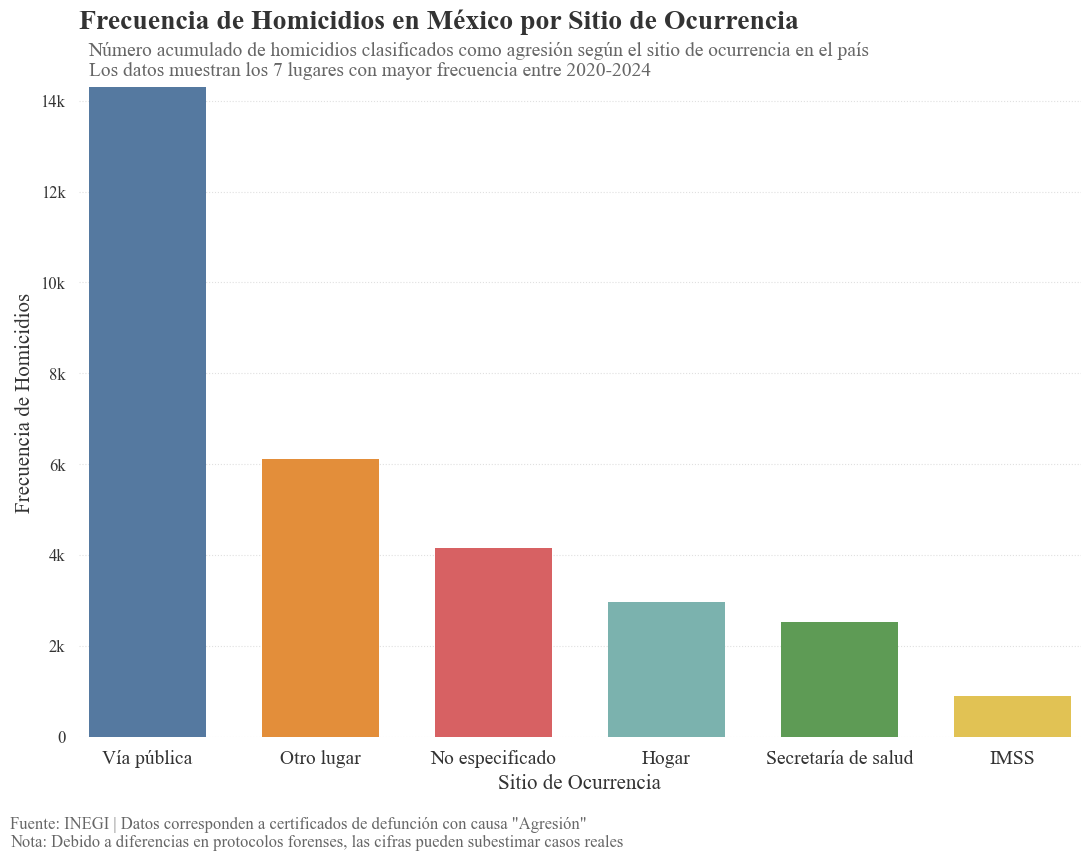

In [7]:
fig, ax = plt.subplots()

(
    homicidios
    .filter(pl.col('tipo_defun') == 'Homicidio (Agresión)')
    .group_by(
        ['sitio_ocur', 'tipo_defun']
    )
    .len()
    .rename(
        {'len': 'Frecuencia'}
    )
    .sort(by = 'Frecuencia', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.barplot(
            data = df,
            x = 'sitio_ocur',
            y = 'Frecuencia',
            palette = owid_palette,
            ax = ax,
            saturation= 0.85,
            width = 0.68,
            edgecolor = 'none',
            linewidth = 0.5
        )
    )
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')
)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Frecuencia de Homicidios en México por Sitio de Ocurrencia', 
            loc='left', pad=28, fontweight='semibold')

ax.text(0.01, 0.988, 'Número acumulado de homicidios clasificados como agresión según el sitio de ocurrencia en el país\n' 
         'Los datos muestran los 7 lugares con mayor frecuencia entre 2020-2024',
        transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
           'Fuente: INEGI | Datos corresponden a certificados de defunción con causa "Agresión"\n'
           'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
           ha='left', color='#666666', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Sitio de Ocurrencia', size=15)
plt.ylabel('Frecuencia de Homicidios', size=15)
sns.despine(left=True, bottom=True)
plt.show()

## Homicidios en México por Sitio de Ocurrencia:

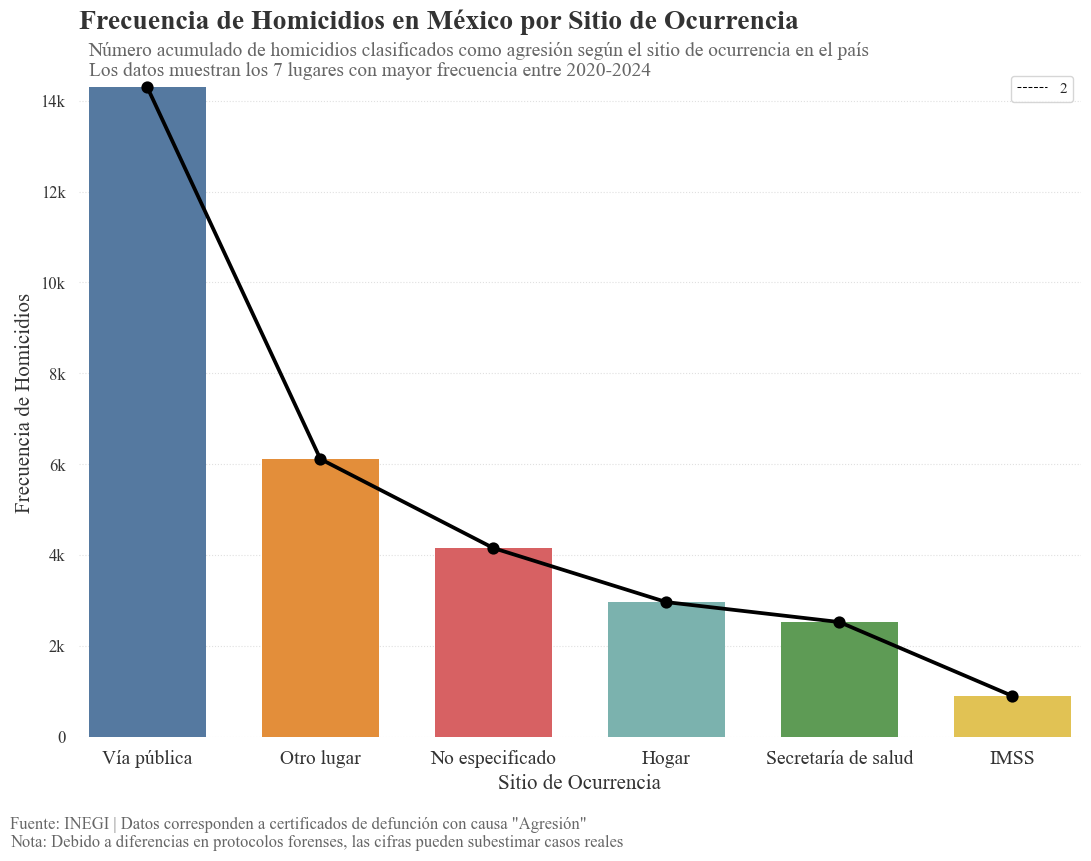

In [8]:
fig, ax = plt.subplots()

(
    homicidios
    .filter(pl.col('tipo_defun') == 'Homicidio (Agresión)')
    .group_by(
        ['sitio_ocur', 'tipo_defun']
    )
    .len()
    .rename(
        {'len': 'Frecuencia'}
    )
    .sort(by = 'Frecuencia', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.barplot(
            data = df,
            x = 'sitio_ocur',
            y = 'Frecuencia',
            palette = owid_palette,
            saturation= 0.85,
            width = 0.68,
            edgecolor='none',
            linewidth= 0.5
        )
    )
)

(
    homicidios
    .filter(pl.col('tipo_defun') == 'Homicidio (Agresión)')
    .group_by(
        ['sitio_ocur', 'tipo_defun']
    )
    .len()
    .rename(
        {'len': 'Frecuencia'}
    )
    .sort(by = 'Frecuencia', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.lineplot(
            data = df,
            x = 'sitio_ocur',
            y = 'Frecuencia',
            color = 'black',
            linestyle = 'dashed',
            size = 2
        )
    )
)

(
    homicidios
    .filter(pl.col('tipo_defun') == 'Homicidio (Agresión)')
    .group_by(
        ['sitio_ocur', 'tipo_defun']
    )
    .len()
    .rename(
        {'len': 'Frecuencia'}
    )
    .sort(by = 'Frecuencia', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.pointplot(
            data = df,
            x = 'sitio_ocur',
            y = 'Frecuencia',
            color = 'black'
        )
    )
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}')
)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Frecuencia de Homicidios en México por Sitio de Ocurrencia', 
            loc='left', pad=28, fontweight='semibold')

ax.text(0.01, 0.988, 'Número acumulado de homicidios clasificados como agresión según el sitio de ocurrencia en el país\n' 
         'Los datos muestran los 7 lugares con mayor frecuencia entre 2020-2024',
        transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
           'Fuente: INEGI | Datos corresponden a certificados de defunción con causa "Agresión"\n'
           'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
           ha='left', color='#666666', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Sitio de Ocurrencia', size=15)
plt.ylabel('Frecuencia de Homicidios', size=15)
sns.despine(left=True, bottom=True)
plt.show()

## Homicidios de Mujeres en México por Sitio de Ocurrencia:

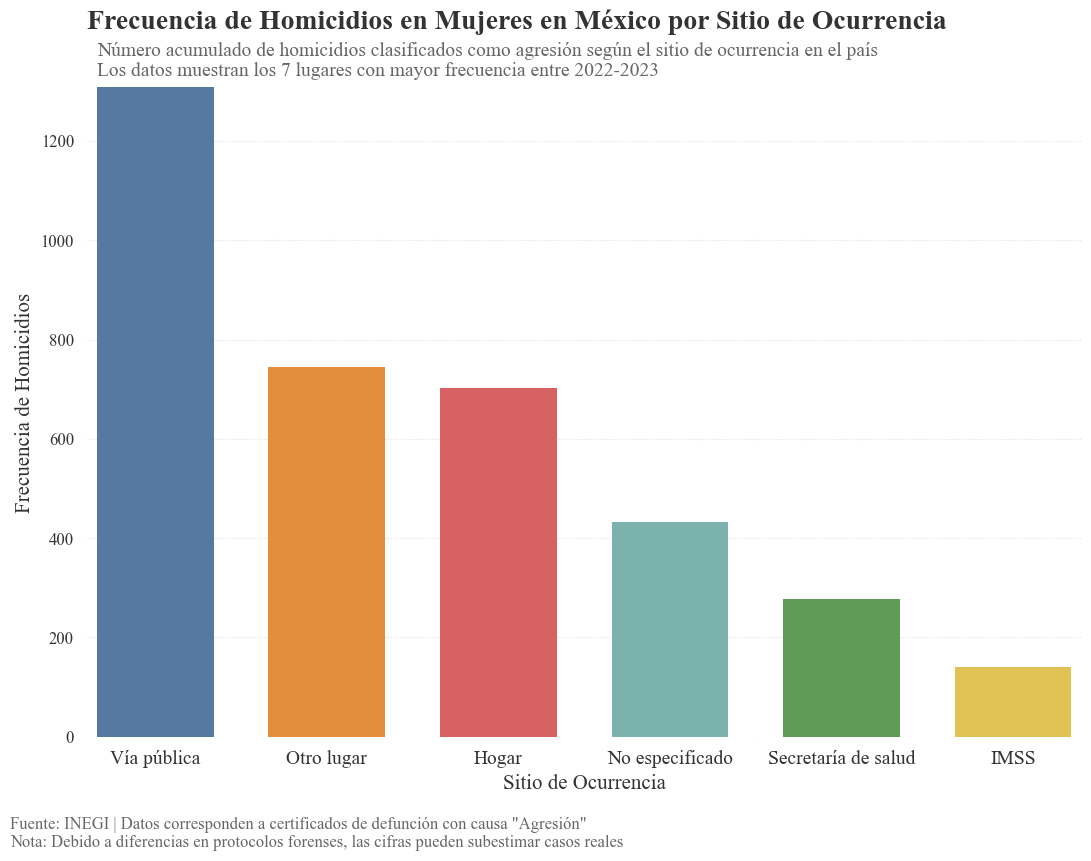

In [10]:
fig, ax = plt.subplots()

(
homicidios
    .filter(
    (pl.col("tipo_defun") == "Homicidio (Agresión)") &
    (pl.col("sexo") == "Mujer")
    )
    .group_by(
        ['sitio_ocur', 'tipo_defun']
    )
    .len()
    .rename(
        {'len': 'Frecuencia'}
    )
    .sort(by = 'Frecuencia', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.barplot(
            data = df,
            x = 'sitio_ocur',
            y = 'Frecuencia',
            palette = owid_palette,
            ax = ax,
            saturation= 0.85,
            width = 0.68,
            edgecolor = 'none',
            linewidth = 0.5
        )
    )
)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Frecuencia de Homicidios en Mujeres en México por Sitio de Ocurrencia', 
            loc='left', pad=28, fontweight='semibold')

ax.text(0.01, 0.988, 'Número acumulado de homicidios clasificados como agresión según el sitio de ocurrencia en el país\n' 
        'Los datos muestran los 7 lugares con mayor frecuencia entre 2022-2023',
        transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
        'Fuente: INEGI | Datos corresponden a certificados de defunción con causa "Agresión"\n'
        'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
        ha='left', color='#666666', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Sitio de Ocurrencia', size=15)
plt.ylabel('Frecuencia de Homicidios', size=15)
sns.despine(left=True, bottom=True)
plt.show()

## Año de Nacimiento de las Personas Fallecidas en México:

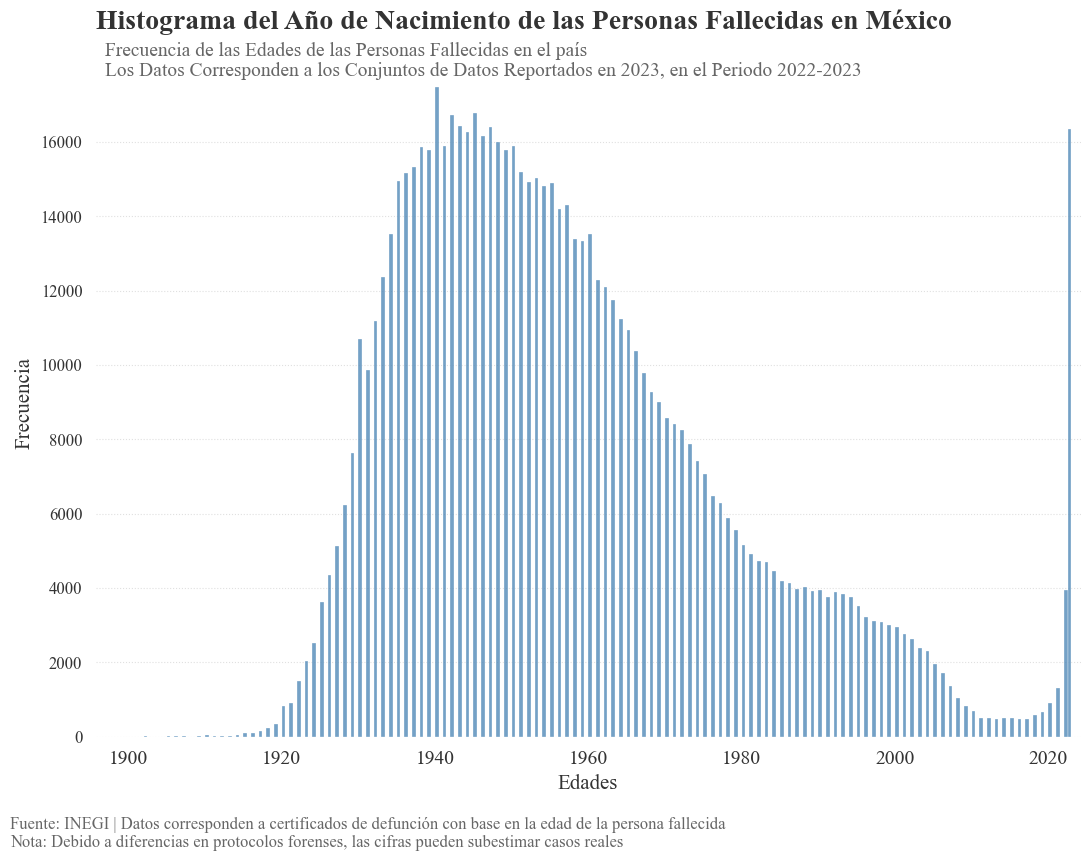

In [14]:
fig, ax = plt.subplots()

(
    homicidios
    .filter(pl.col('anio_nacim') != 9999)
    .to_pandas()
    .pipe(
        lambda df: sns.histplot(
            data = df,
            x = 'anio_nacim',
            binwidth=0.5,
            color = 'steelblue'
        )
    )
)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
    
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Histograma del Año de Nacimiento de las Personas Fallecidas en México', 
            loc='left', pad=28, fontweight='semibold')

ax.text(0.01, 0.988, 'Frecuencia de las Edades de las Personas Fallecidas en el país\n' 
            'Los Datos Corresponden a los Conjuntos de Datos Reportados en 2023, en el Periodo 2022-2023',
            transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
        'Fuente: INEGI | Datos corresponden a certificados de defunción con base en la edad de la persona fallecida\n'
        'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
        ha='left', color='#666666', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Edades', size=15)
plt.ylabel('Frecuencia', size=15)
sns.despine(left=True, bottom=True)
plt.show()

## Distribución de las Edades de las Personas Fallecidas en México:

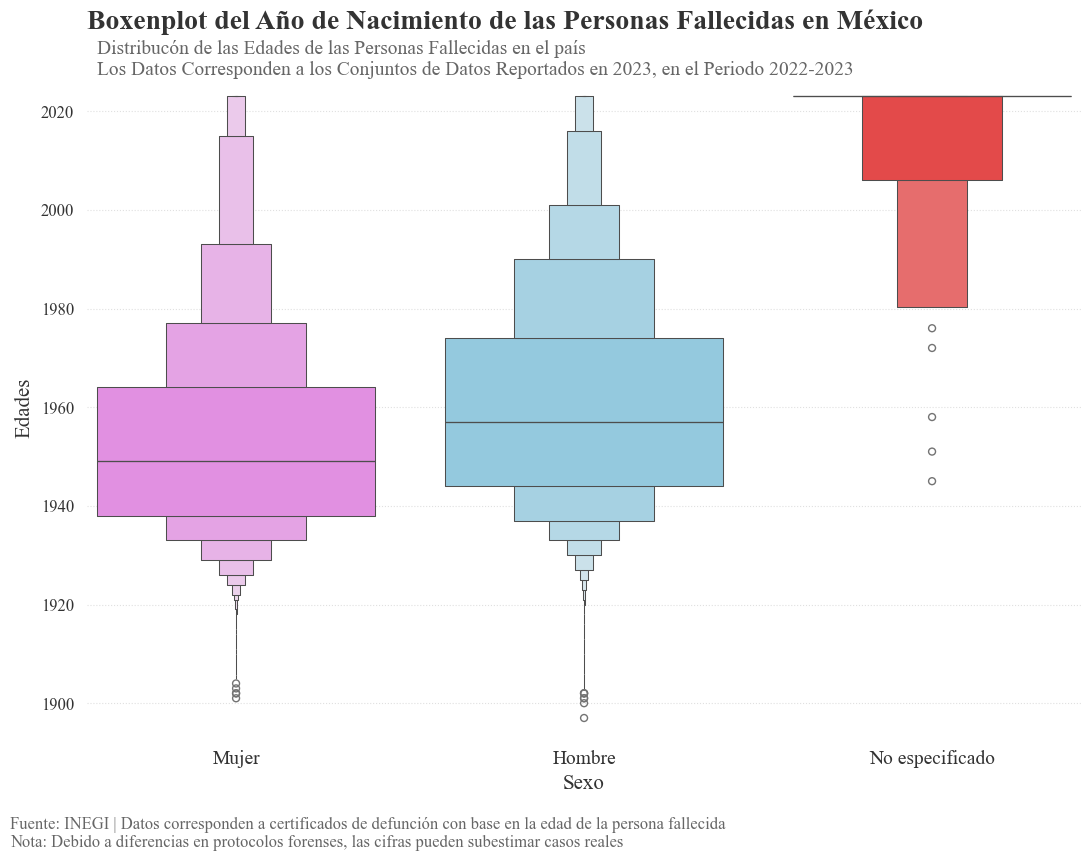

In [15]:
fig, ax = plt.subplots()

(
    homicidios
    .filter(pl.col('anio_nacim') != 9999)
    .to_pandas()
    .pipe(
        lambda df: sns.boxenplot(
            data = df,
            x = 'sexo',
            y = 'anio_nacim',
            palette = gender_palette
        )
    )
)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Boxenplot del Año de Nacimiento de las Personas Fallecidas en México', 
            loc='left', pad=35, fontweight='semibold')

ax.text(0.01, 1.005, 'Distribucón de las Edades de las Personas Fallecidas en el país\n' 
        'Los Datos Corresponden a los Conjuntos de Datos Reportados en 2023, en el Periodo 2022-2023',
        transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
        'Fuente: INEGI | Datos corresponden a certificados de defunción con base en la edad de la persona fallecida\n'
        'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
        ha='left', color='#666666', fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Sexo', size=15)
plt.ylabel('Edades', size=15)
sns.despine(left=True, bottom=True)
plt.show()

## Principales Motivos de Fallecimiento en México:

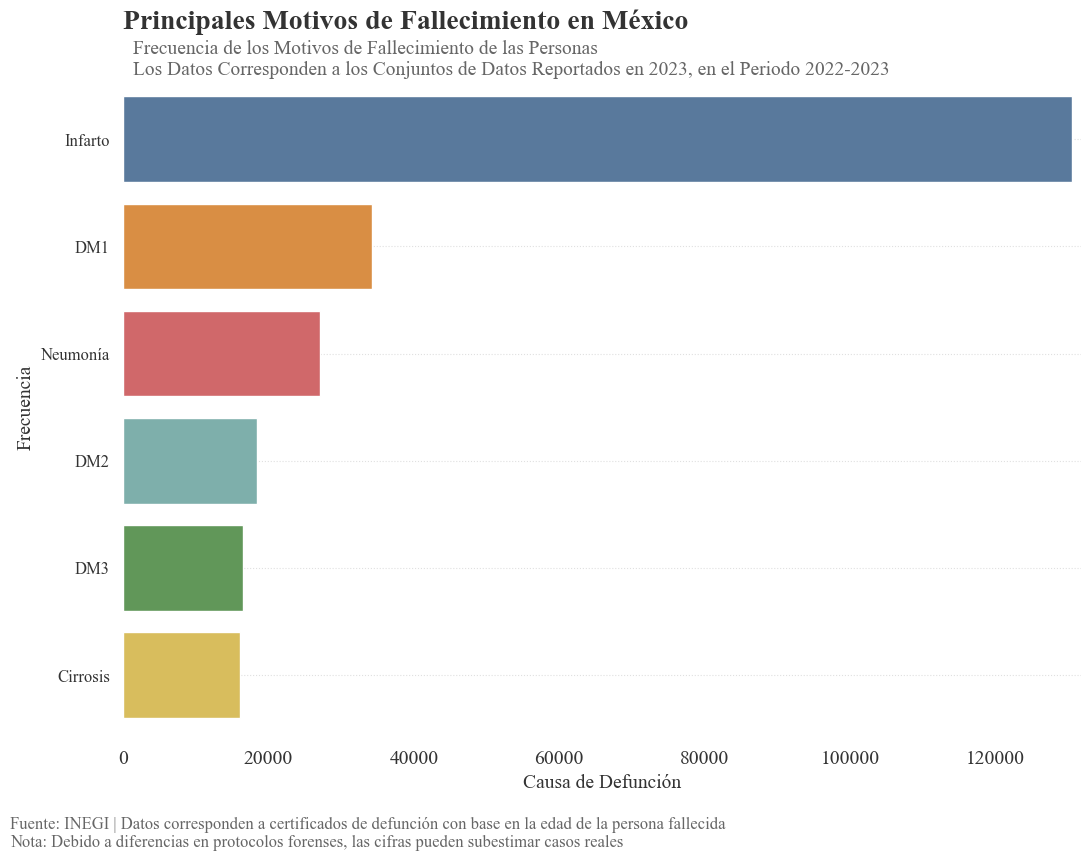

In [16]:
fig, ax = plt.subplots()

(
    homicidios['causa_def']
    .value_counts()
    .sort(by = 'count', descending= True)
    .head(6)
    .to_pandas()
    .pipe(
        lambda df: sns.barplot(
            data=df,
            x= 'count',
            y = 'causa_def',
            palette = owid_palette,
            ax=ax
        )
    )
)

etiquetas_cortas = ['Infarto', 'DM1', 'Neumonía', 'DM2', 'DM3', 'Cirrosis']

ax.set_yticklabels(etiquetas_cortas, rotation=0)

ax.xaxis.set_tick_params(rotation=0, labelsize=14)
    
plt.setp(ax.get_xticklabels(), horizontalalignment='center')

ax.set_title('Principales Motivos de Fallecimiento en México', 
            loc='left', pad=35, fontweight='semibold')

ax.text(0.01, 1.005, 'Frecuencia de los Motivos de Fallecimiento de las Personas\n' 
            'Los Datos Corresponden a los Conjuntos de Datos Reportados en 2023, en el Periodo 2022-2023',
            transform=ax.transAxes, fontsize=14, color='#666666')

ax.grid(True, axis='y', color='#e0e0e0', linestyle=':', linewidth=0.8)
ax.margins(x=0.01, y=0.03)

plt.figtext(0.01, 0.04, 
        'Fuente: INEGI | Datos corresponden a certificados de defunción con base en la edad de la persona fallecida\n'
        'Nota: Debido a diferencias en protocolos forenses, las cifras pueden subestimar casos reales',
        ha='left', color='#666666', fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.xlabel('Causa de Defunción')
plt.ylabel('Frecuencia')
plt.show()